In [1]:
# Copyright (C) 2026 ETH Zurich, Shu-Yu Chen
import sys
# Save original path
original_sys_path = sys.path.copy()
# Remove custom entries not in original sys.path (like PYTHONPATH entries) to avoid numpy conflict
sys.path = [p for p in sys.path if "amber" not in p]
for i, path in enumerate(sys.path):
    print(f"{i}: {path}")

0: /localhome/shuchen/.conda/envs/ALG8_pytraj/lib/python36.zip
1: /localhome/shuchen/.conda/envs/ALG8_pytraj/lib/python3.6
2: /localhome/shuchen/.conda/envs/ALG8_pytraj/lib/python3.6/lib-dynload
3: 
4: /localhome/shuchen/.conda/envs/ALG8_pytraj/lib/python3.6/site-packages
5: /localhome/shuchen/.conda/envs/ALG8_pytraj/lib/python3.6/site-packages/IPython/extensions
6: /home/shuchen/.ipython


In [2]:
from ALG8_class import *
import os
import seaborn as sns
suffixes = ['epsilon', 'delta', 'double']

# %load_ext autoreload
# %autoreload 2
import matplotlib.pyplot as plt

plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 18
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12


# Load object

In [3]:
# Analyze the data if you don't have the pkl results yet
# adjust do your own path
from ALG8_class import *
object_path = "./objects/"
figdir = './Figures/ALG8_posttransfer/'
# create the directory if it doesn't exist
if not os.path.exists(figdir):
    os.makedirs(figdir)
N_run = 5
# wt with Glc
prefixes = ['ALG8_D36_post_transfer', 'ALG8_D36_H40d_post_transfer', 'ALG8_D36_H40db_post_transfer',
            'ALG8_N36_post_transfer', 'ALG8_N36_H40d_post_transfer', 'ALG8_N36_H40db_post_transfer',
            ]
objs_out = [[object_path+f'{prefix}_run{run}_analysis_obj.pkl' for run in range(1,N_run+1)] for prefix in prefixes]

object_names = [r'$Hs$ALG8 D36 (H40$_{\epsilon}$)', r'$Hs$ALG8 D36 (H40$_{\delta}$)', r'$Hs$ALG8 D36 (H40$_{double}$)',
                r'$Hs$ALG8 N36 (H40$_{\epsilon}$)', r'$Hs$ALG8 N36 (H40$_{\delta}$)', r'$Hs$ALG8 N36 (H40$_{double}$)',
                ]

object_lists = [[] for i in range(len(object_names))]
for i_list, object_list in enumerate(object_lists):
    # load
    for i_obj in range(N_run):
        obj_file = objs_out[i_list][i_obj]
        if os.path.exists(obj_file):
            obj = pickle.load(open(obj_file, 'rb'))
            object_list.append(obj)
        else:
            print(f"File {obj_file} not found. Please run the analysis to generate it.")


## RMSD

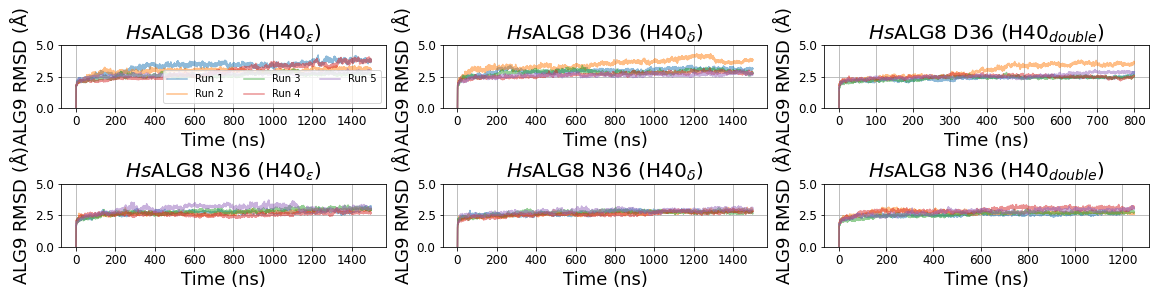

In [4]:
fig, axs = plt.subplots(2,3,figsize=(16,4))
ylim = [0,5]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsd[i_obj] = obj.pro_rmsd
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
        ax.plot(x,obj.pro_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_xlabel('Time (ns)')
    ax.set_title(object_names[i_object_list])
    ax.set_ylabel(r'ALG9 RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_ALG8.svg'
plt.savefig(filename)

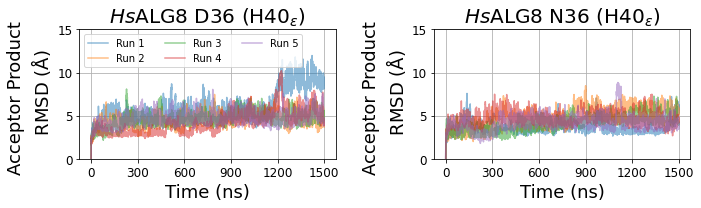

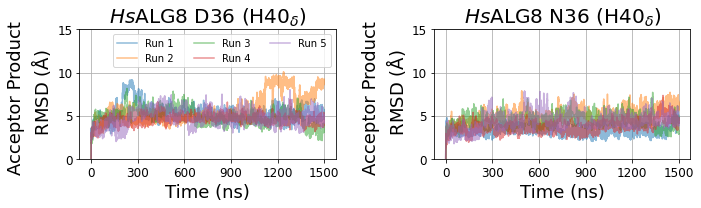

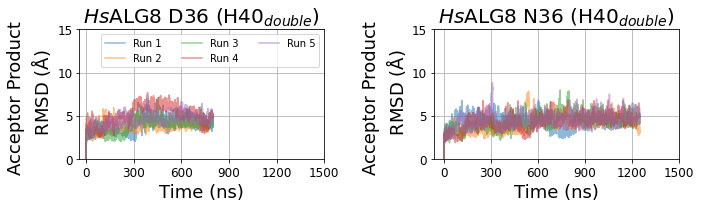

In [5]:
ylim = [0,15]
xticks = np.arange(0,1501,300)
for offset in range(3):
    use_id  = [offset, offset+3]
    fig, axs = plt.subplots(1,2,figsize=(10,3))
    for i_object_list, object_list in enumerate([object_lists[j] for j in use_id]):
        ax = axs[i_object_list]
        rmsd = [np.array] * len(object_list)
        for i_obj, obj in enumerate(object_list):
            rmsd[i_obj] = obj.AS_rmsd
            x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
            ax.plot(x,obj.AS_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
        if i_object_list == 0:
            ax.legend(ncol=3)
        ax.set_ylim(ylim)
        ax.set_title(object_names[use_id[i_object_list]])
        ax.set_xticks(xticks)
        ax.set_xlabel('Time (ns)')
        ax.set_ylabel('Acceptor Product \n RMSD ' +r'($\rm \AA$)')
        ax.grid()
    plt.tight_layout()
    filename = figdir+f'RMSD_AS_{suffixes[offset]}.png'
    plt.savefig(filename, dpi=300)

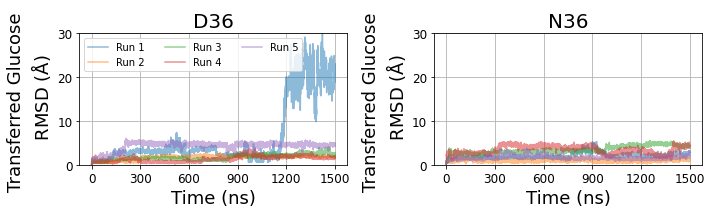

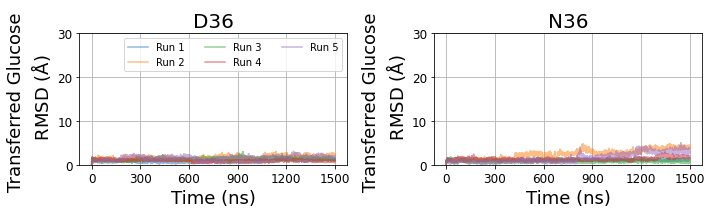

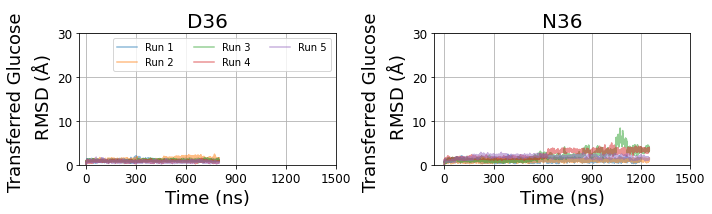

In [6]:
ylim = [0,30]
titles = ['D36', 'N36']
xticks = np.arange(0,1501,300)
for offset in range(3):
    use_id  = [offset, offset+3]
    fig, axs = plt.subplots(1,2,figsize=(10,3))
    for i_object_list, object_list in enumerate([object_lists[j] for j in use_id]):
        ax = axs[i_object_list]
        rmsd = [np.array] * len(object_list)
        for i_obj, obj in enumerate(object_list):
            x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
            ax.plot(x,obj.D_sugar_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
        if i_object_list == 0:
            ax.legend(ncol=3)
        ax.set_ylim(ylim)
        ax.set_title(titles[i_object_list])
        ax.set_xticks(xticks)
        ax.set_xlabel('Time (ns)')
        ax.set_ylabel('Transferred Glucose \n RMSD ' +r'($\rm \AA$)')
        ax.grid()
    plt.tight_layout()
    filename = figdir+f'RMSD_DSugar_{suffixes[offset]}.png'
    plt.savefig(filename, dpi=300)

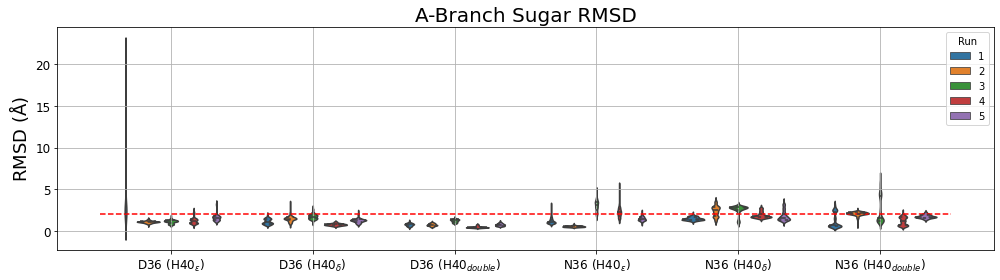

In [7]:
fig, axs = plt.subplots(1,1,figsize=(14,4))
rmsd_cutoff = 2.0
df = pd.DataFrame()
sliding_window = 10
discard_ratio = 0.1
for i_object_list, object_list in enumerate(object_lists):
    # violin plot for DP RMSD
    for i_obj, obj in enumerate(object_list):
        df_ = pd.DataFrame()
        df_['AS RMSD'] = sliding_average(obj.A_sugar_rmsd[int(len(obj.pro_rmsd)*discard_ratio):], window_size=sliding_window)
        df_['Object'] = ' '.join(object_names[i_object_list].split(' ')[1:])
        df_['Run'] = i_obj + 1
        df = pd.concat([df, df_], ignore_index=True)
sns.violinplot(x='Object', y='AS RMSD', hue='Run', data=df,  inner='quartile')
plt.hlines(rmsd_cutoff, -0.5, len(object_lists)-0.5, colors='r', linestyles='dashed', label='RMSD Cutoff')
# plt.text(len(object_lists)-0.5, rmsd_cutoff+0.1, 'RMSD Cutoff', color='r', va='bottom', ha='right')
plt.title('A-Branch Sugar RMSD')
plt.ylabel(r'RMSD ($\rm \AA$)')
plt.xlabel('')
plt.grid()
plt.tight_layout()
filename = figdir+'Violin_Asugar_RMSD.svg'
plt.savefig(filename)

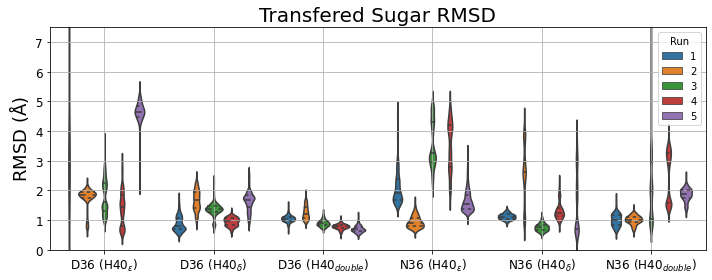

In [8]:
fig, axs = plt.subplots(1,1,figsize=(10,4))
rmsd_cutoff = 2.0
df = pd.DataFrame()
sliding_window = 10
discard_ratio = 0.1
for i_object_list, object_list in enumerate(object_lists):
    # violin plot for DP RMSD
    for i_obj, obj in enumerate(object_list):
        df_ = pd.DataFrame()
        df_['AS RMSD'] = sliding_average(obj.D_sugar_rmsd[int(len(obj.pro_rmsd)*discard_ratio):], window_size=sliding_window)
        df_['Object'] = ' '.join(object_names[i_object_list].split(' ')[1:])
        df_['Run'] = i_obj + 1
        df = pd.concat([df, df_], ignore_index=True)
sns.violinplot(x='Object', y='AS RMSD', hue='Run', data=df,  inner='quartile')
# plt.hlines(rmsd_cutoff, -0.5, len(object_lists)-0.5, colors='r', linestyles='dashed', label='RMSD Cutoff')
# plt.text(len(object_lists)-0.5, rmsd_cutoff+0.1, 'RMSD Cutoff', color='r', va='bottom', ha='right')
plt.title('Transfered Sugar RMSD')
plt.ylabel(r'RMSD ($\rm \AA$)')
plt.ylim(0,7.5)
plt.xlabel('')
plt.grid()
plt.tight_layout()
filename = figdir+'Violin_Dsugar_RMSD.png'
plt.savefig(filename, dpi=300)

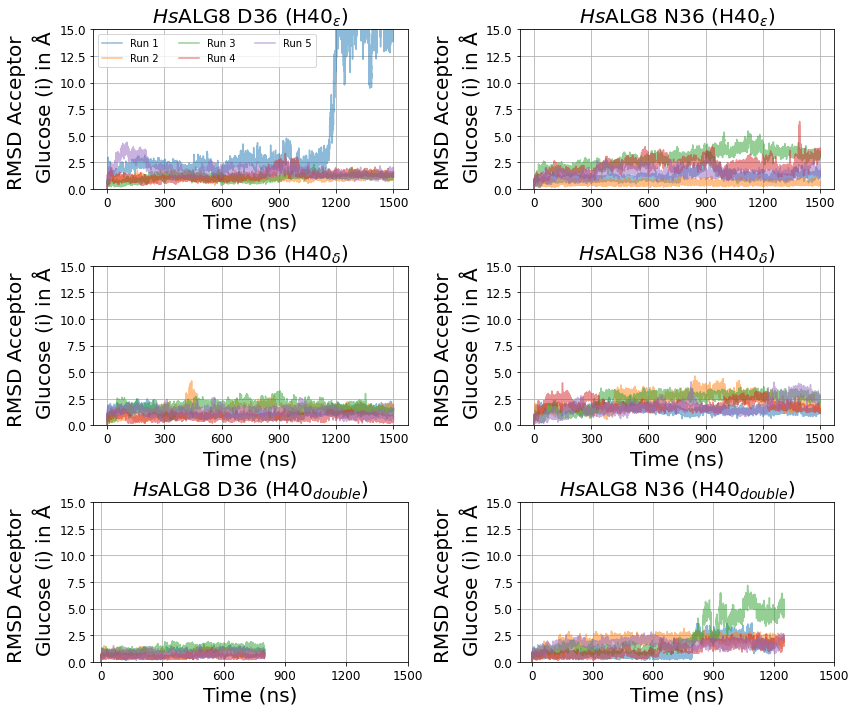

In [ ]:
# Donor A-sugar RMSD

fig, axs = plt.subplots(len(object_lists)//2, 2,figsize=(12,10))
ylim = [0,15]
xticks = np.arange(0,1501,300)
for i_object_list, object_list in enumerate(object_lists):
    # ax = axs.flatten()[i_object_list]
    ax = axs.T.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsd[i_obj] = obj.A_sugar_rmsd
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
        ax.plot(x,obj.A_sugar_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_xticks(xticks)
    ax.set_title(object_names[i_object_list], fontsize=20)
    ax.set_xlabel('Time (ns)', fontsize=20)
    ax.set_ylabel('RMSD Acceptor \n Glucose (i) in ' +r'$\rm \AA$', fontsize=20)
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_Asugar.png'
plt.savefig(filename)

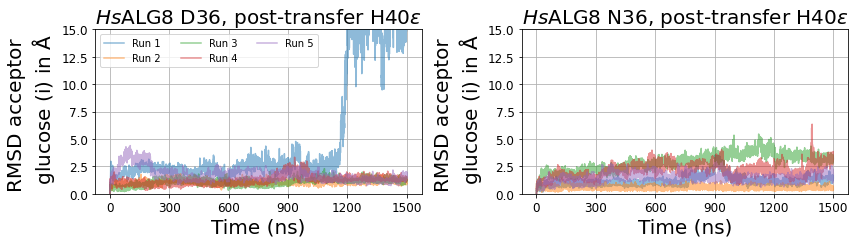

In [65]:

titles = [r'$Hs$ALG8 D36, post-transfer H40${\epsilon}$', r'$Hs$ALG8 N36, post-transfer H40${\epsilon}$']
# Donor A-sugar RMSD
fig, axs = plt.subplots(1, 2,figsize=(12,3.5))
ylim = [0,15]
xticks = np.arange(0,1501,300)
for i_object_list, object_list in enumerate([object_lists[0], object_lists[3]]):
    # ax = axs.flatten()[i_object_list]
    ax = axs.T.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsd[i_obj] = obj.A_sugar_rmsd
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
        ax.plot(x,obj.A_sugar_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_xticks(xticks)
    ax.set_title(titles[i_object_list], fontsize=20)
    ax.set_xlabel('Time (ns)', fontsize=20)
    ax.set_ylabel('RMSD acceptor \n glucose (i) in ' +r'$\rm \AA$', fontsize=20)
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_Glu_i_epsilon.png'
plt.savefig(filename)

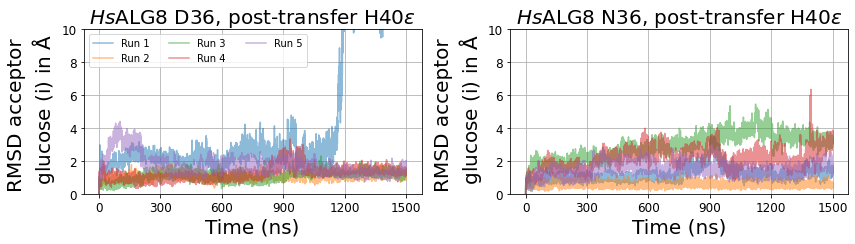

In [66]:

titles = [r'$Hs$ALG8 D36, post-transfer H40${\epsilon}$', r'$Hs$ALG8 N36, post-transfer H40${\epsilon}$']
# Donor A-sugar RMSD
fig, axs = plt.subplots(1, 2,figsize=(12,3.5))
ylim = [0,10]
xticks = np.arange(0,1501,300)
for i_object_list, object_list in enumerate([object_lists[0], object_lists[3]]):
    # ax = axs.flatten()[i_object_list]
    ax = axs.T.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsd[i_obj] = obj.A_sugar_rmsd
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
        ax.plot(x,obj.A_sugar_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_xticks(xticks)
    ax.set_title(titles[i_object_list], fontsize=20)
    ax.set_xlabel('Time (ns)', fontsize=20)
    ax.set_ylabel('RMSD acceptor \n glucose (i) in ' +r'$\rm \AA$', fontsize=20)
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_Glu_i_epsilon_y10A.png'
plt.savefig(filename)

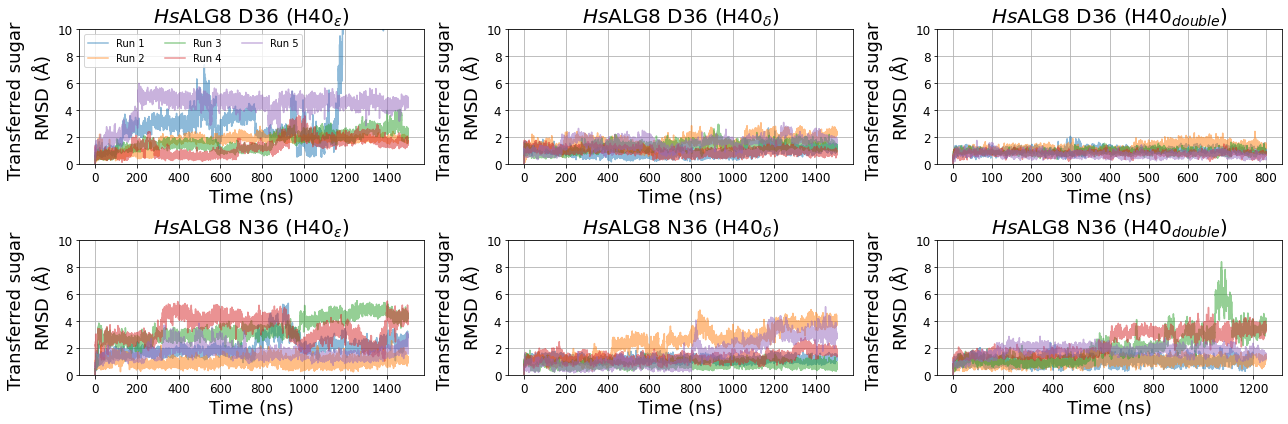

In [10]:
# Donor A-sugar RMSD
fig, axs = plt.subplots(2,len(object_lists)//2,figsize=(3*len(object_lists),6))
ylim = [0,10]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsd[i_obj] = obj.D_sugar_rmsd
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
        ax.plot(x,obj.D_sugar_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_title(object_names[i_object_list])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('Transferred sugar \n' +r'RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_Dsugar.png'
plt.savefig(filename)

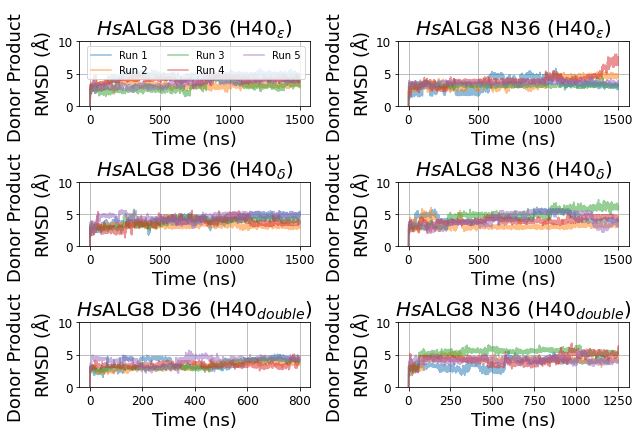

In [11]:
# Donor A-sugar RMSD
fig, axs = plt.subplots(len(object_lists)//2, 2,figsize=(9,6))
ylim = [0,10]
for i_object_list, object_list in enumerate(object_lists):
    # ax = axs.flatten()[i_object_list]
    ax = axs.T.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsd[i_obj] = obj.DSP_rmsd
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
        ax.plot(x,obj.DSP_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_title(object_names[i_object_list])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('Donor Product \n' +r'RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_DP.png'
plt.savefig(filename)

# RMSF plots

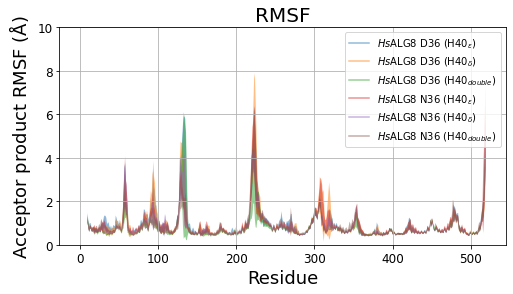

In [12]:
fig, axs = plt.subplots(1,1,figsize=(8,4))
ylim = [0,10]
resid_offset = 10
for i_object_list, object_list in enumerate(object_lists):
    rmsf = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsf[i_obj] = obj.pro_rmsf[:,1]
    rmsf = np.array(rmsf)
    axs.plot(rmsf.mean(axis=0)+resid_offset, label = f'{object_names[i_object_list]}',alpha=0.5)
    axs.fill_between(np.arange(len(obj.pro_rmsf[:,0]))+resid_offset,rmsf.mean(axis=0)-rmsf.std(axis=0),rmsf.mean(axis=0)+rmsf.std(axis=0),alpha=0.5)
axs.legend()
# axs.set_xlim([resid_offset, len(obj.DS_rmsf[:,0])+resid_offset])
axs.set_ylim(ylim)
axs.grid()
axs.set_title('RMSF')
axs.set_xlabel('Residue')
axs.set_ylabel(r'Acceptor product RMSF ($\rm \AA$)')
filename = figdir+'RMSF_ALG8.svg'
plt.savefig(filename)

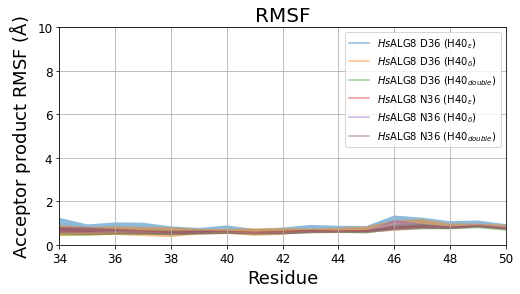

In [13]:
fig, axs = plt.subplots(1,1,figsize=(8,4))
ylim = [0,10]
xlim  =[24,40]
resid_offset = 10
for i_object_list, object_list in enumerate(object_lists):
    rmsf = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsf[i_obj] = obj.pro_rmsf[:,1]
    rmsf = np.array(rmsf)
    axs.plot(rmsf.mean(axis=0)+resid_offset, label = f'{object_names[i_object_list]}',alpha=0.5)
    axs.fill_between(np.arange(len(obj.pro_rmsf[:,0]))+resid_offset,rmsf.mean(axis=0)-rmsf.std(axis=0),rmsf.mean(axis=0)+rmsf.std(axis=0),alpha=0.5)
axs.legend()
axs.set_xlim([xlim[0]+resid_offset, xlim[1]+resid_offset])
axs.set_ylim(ylim)
axs.grid()
axs.set_title('RMSF')
axs.set_xlabel('Residue')
axs.set_ylabel(r'Acceptor product RMSF ($\rm \AA$)')
filename = figdir+'RMSF_ALG8_S34-L50.svg'
plt.savefig(filename)

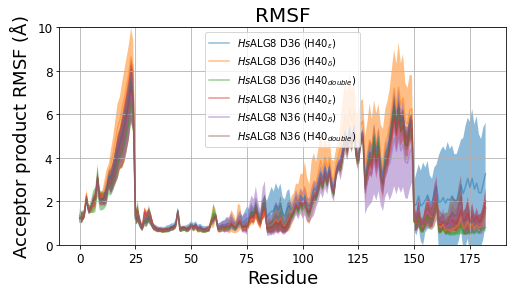

In [14]:
fig, axs = plt.subplots(1,1,figsize=(8,4))
ylim = [0,10]
resid_offset = 0
for i_object_list, object_list in enumerate(object_lists):
    rmsf = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsf[i_obj] = obj.AS_rmsf[:,1]
    rmsf = np.array(rmsf)
    axs.plot(rmsf.mean(axis=0)+resid_offset, label = f'{object_names[i_object_list]}',alpha=0.5)
    axs.fill_between(np.arange(len(obj.AS_rmsf[:,0]))+resid_offset,rmsf.mean(axis=0)-rmsf.std(axis=0),rmsf.mean(axis=0)+rmsf.std(axis=0),alpha=0.5)
axs.legend()
# axs.set_xlim([resid_offset, len(obj.DS_rmsf[:,0])+resid_offset])
axs.set_ylim(ylim)
axs.grid()
axs.set_title('RMSF')
axs.set_xlabel('Residue')
axs.set_ylabel(r'Acceptor product RMSF ($\rm \AA$)')
filename = figdir+'RMSF_AP.svg'
plt.savefig(filename)

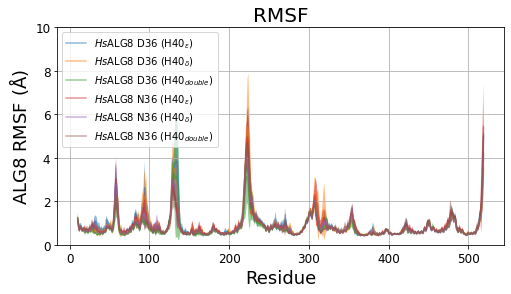

In [15]:
fig, axs = plt.subplots(1,1,figsize=(8,4))
ylim = [0,10]
resid_offset = 10
for i_object_list, object_list in enumerate(object_lists):
    rmsf = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsf[i_obj] = obj.pro_rmsf[:,1]
    rmsf = np.array(rmsf)
    
    axs.plot(np.arange(len(obj.pro_rmsf[:,0]))+resid_offset, rmsf.mean(axis=0), label = f'{object_names[i_object_list]}',alpha=0.5)
    axs.fill_between(np.arange(len(obj.pro_rmsf[:,0]))+resid_offset,rmsf.mean(axis=0)-rmsf.std(axis=0),rmsf.mean(axis=0)+rmsf.std(axis=0),alpha=0.5)
axs.grid()
axs.legend()
# axs.set_xlim([resid_offset, len(obj.protein_rmsf[:,0])+resid_offset])
axs.set_ylim(ylim)
axs.set_title('RMSF')
axs.set_xlabel('Residue')
axs.set_ylabel(r'ALG8 RMSF ($\rm \AA$)')
filename = figdir+'RMSF_ALG8.svg'
plt.savefig(filename)

Text(0, 0.5, 'ALG8 RMSF ($\\rm \\AA$)')

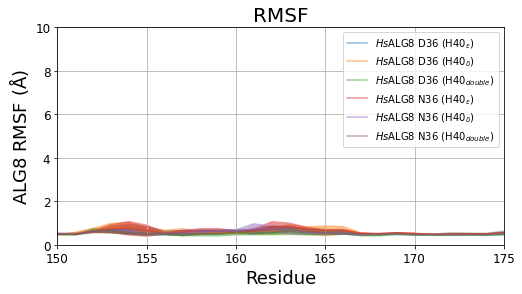

In [16]:
fig, axs = plt.subplots(1,1,figsize=(8,4))
ylim = [0,10]
xlim = [150,175]
resid_offset = 10
for i_object_list, object_list in enumerate(object_lists):
    rmsf = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsf[i_obj] = obj.pro_rmsf[:,1]
    rmsf = np.array(rmsf)
    
    axs.plot(np.arange(len(obj.pro_rmsf[:,0]))+resid_offset, rmsf.mean(axis=0), label = f'{object_names[i_object_list]}',alpha=0.5)
    axs.fill_between(np.arange(len(obj.pro_rmsf[:,0]))+resid_offset,rmsf.mean(axis=0)-rmsf.std(axis=0),rmsf.mean(axis=0)+rmsf.std(axis=0),alpha=0.5)
axs.grid()
axs.legend()
# axs.set_xlim([resid_offset, len(obj.protein_rmsf[:,0])+resid_offset])
axs.set_ylim(ylim)
axs.set_xlim(xlim)
axs.set_title('RMSF')
axs.set_xlabel('Residue')
axs.set_ylabel(r'ALG8 RMSF ($\rm \AA$)')


# Hbond to the donor and D66

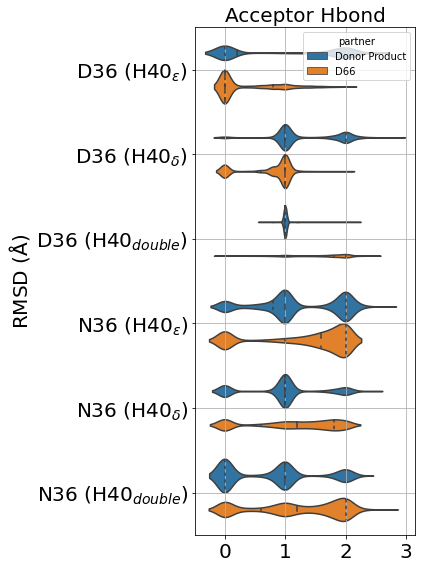

In [17]:
# Product Hbond (acceptor product and donor product)
fig, axs = plt.subplots(1,1,figsize=(6,8))
rmsd_cutoff = 2.0

sliding_window = 5
discard_ratio = 0.8
df = pd.DataFrame()
for i_object_list, object_list in enumerate(object_lists):
    # violin plot for DP RMSD
    for i_obj, obj in enumerate(object_list):
        # AP and DP Hbond
        df_ = pd.DataFrame()
        df_['Hbond']  = sliding_average(obj.intra_hydrogen_bonds[0,1,int(len(obj.pro_rmsd)*discard_ratio):], window_size=sliding_window)
        df_['partner'] = 'Donor Product'
        df_['Object'] = ' '.join(object_names[i_object_list].split(' ')[1:])
        df_['Run'] = i_obj + 1
        df = pd.concat([df, df_], ignore_index=True)
        # D66 Hbond
        df_['Hbond']   = sliding_average(obj.protein_substrates_bonds[0,6][int(len(obj.pro_rmsd)*discard_ratio):], window_size=sliding_window)
        df_['partner'] = 'D66'
        df = pd.concat([df, df_], ignore_index=True)
sns.violinplot(y='Object', x='Hbond', hue='partner', data=df, orient='h', inner='quartile')

# plt.hlines(rmsd_cutoff, -0.5, len(object_lists)-0.5, colors='r', linestyles='dashed', label='RMSD Cutoff')
# plt.text(len(object_lists)-0.5, rmsd_cutoff+0.1, 'RMSD Cutoff', color='r', va='bottom', ha='right')
plt.title('Acceptor Hbond', fontsize=20)
plt.ylabel(r'RMSD ($\rm \AA$)', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.xlabel('')
plt.grid()
plt.tight_layout()
filename = figdir+'Violin_Acceptor_Hbond.png'
plt.savefig(filename)

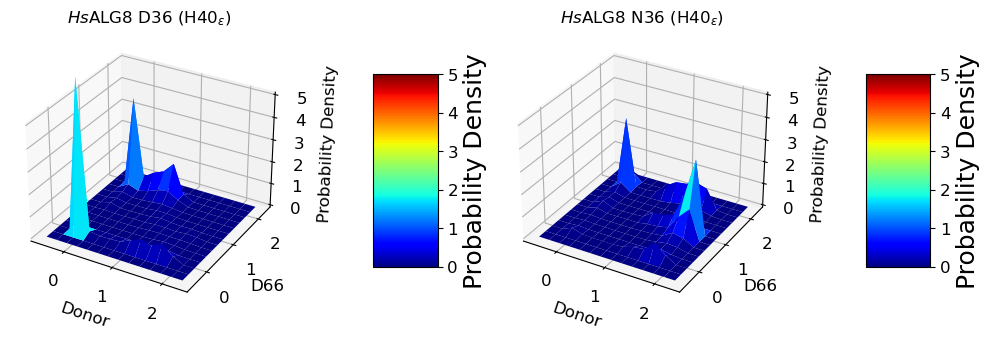

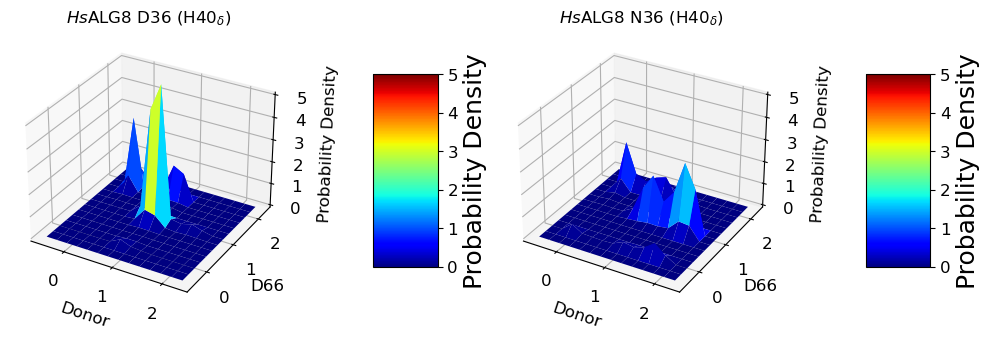

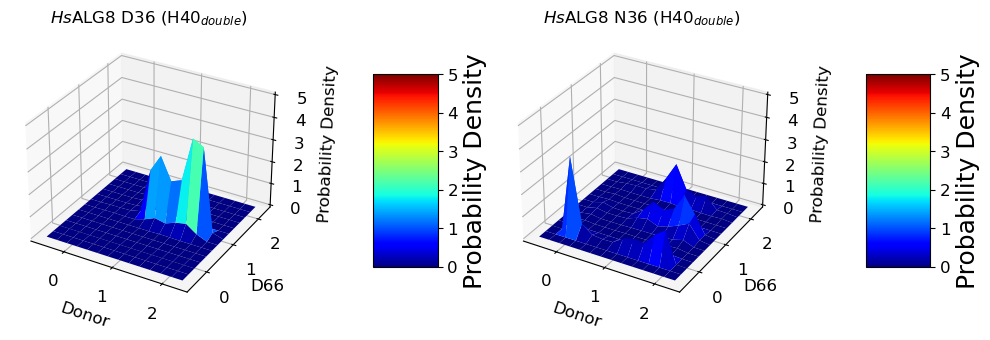

In [18]:
# 1D plots and saving
discard_ratio = 0.6
log = False
cmap = 'Blues'
sliding_window = 20
for offset in range(3):
    fig, axs = plt.subplots(1,2,figsize=(10,12),dpi=100,subplot_kw={'projection': '3d'})
    show_idx = [offset, offset+3]
    for i, object_list in enumerate([object_lists[j] for j in show_idx]):
        acceptor_donor_hbond = np.concatenate([sliding_average(obj.intra_hydrogen_bonds[0,1,int(len(obj.pro_rmsd)*discard_ratio):], 
                                                            window_size=sliding_window) for obj in object_list])
        acceptor_D66_hbond = np.concatenate([sliding_average(obj.protein_substrates_bonds[0,6][int(len(obj.pro_rmsd)*discard_ratio):], 
                                                            window_size=sliding_window) for obj in object_list])
        ax = axs.T.flatten()[i]
        # def plot_hbond_angle(self, ax,r,theta, cmap='Blues',log=False):
        # Plot the histogram in half polar coordinates
        binsize_hbond = 0.2
        Hbond_edges     = np.linspace(-0.5,2.5, 15)

        H, _, _ = np.histogram2d(
            acceptor_donor_hbond,acceptor_D66_hbond ,bins=(Hbond_edges, Hbond_edges),density=True)
        # H[H==0] = np.nan
        x,y  = np.meshgrid(Hbond_edges, Hbond_edges)
        x = 0.5 * (x[:-1,:-1] + x[1:,:-1])
        y = 0.5 * (y[:-1,:-1] + y[:-1,1:])
        im = ax.plot_surface(x,y, H, cmap=plt.cm.jet)
        im.set_clim(0,5)

        ax.set_title(object_names[show_idx[i]], fontsize=12)
        ax.set_zlim(0,5)
        ax.set_xlabel("Donor", fontsize=12)
        ax.set_ylabel("D66", fontsize=12)
        ax.set_zlabel('Probability Density', fontsize=12)
        fig.colorbar(im, ax=ax, orientation='vertical',label='Probability Density',shrink=0.2, aspect=3, pad=0.2)

    plt.tight_layout()
    filename = figdir+f'2D_Hbond_D66_Donor_{suffixes[offset]}.png'
    plt.savefig(filename, dpi=300)


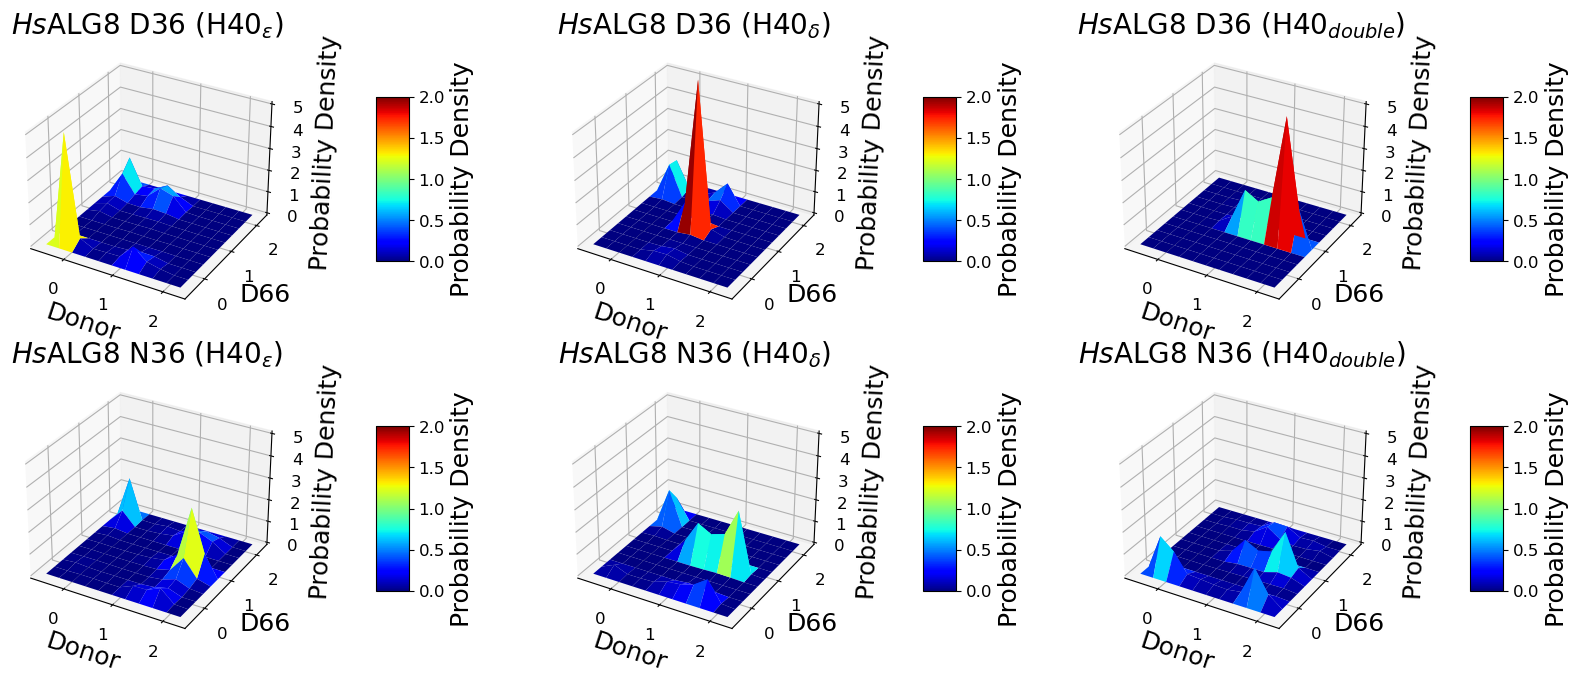

In [19]:
# fig = plt.figure(figsize=plt.figaspect(0.5))
fig = plt.figure(figsize=(20,8),dpi=100)
discard_ratio = 0.8
log = False
cmap = 'Blues'
sliding_window = 20
for i, object_list in enumerate(object_lists):
    
    acceptor_donor_hbond = np.concatenate([sliding_average(obj.intra_hydrogen_bonds[0,1,int(len(obj.pro_rmsd)*discard_ratio):], 
                                                          window_size=sliding_window) for obj in object_list])
    acceptor_D66_hbond = np.concatenate([sliding_average(obj.protein_substrates_bonds[0,6][int(len(obj.pro_rmsd)*discard_ratio):], 
                                                          window_size=sliding_window) for obj in object_list])
    ax = fig.add_subplot(2,3,i+1 , projection='3d')
    # def plot_hbond_angle(self, ax,r,theta, cmap='Blues',log=False):
    # Plot the histogram in half polar coordinates
    binsize_hbond = 0.2
    Hbond_edges     = np.linspace(-0.5,2.5, 12)

    H, _, _ = np.histogram2d(
        acceptor_donor_hbond,acceptor_D66_hbond ,bins=(Hbond_edges, Hbond_edges),density=True)
    # H[H==0] = np.nan
    x,y  = np.meshgrid(Hbond_edges, Hbond_edges)
    x = 0.5 * (x[:-1,:-1] + x[1:,:-1])
    y = 0.5 * (y[:-1,:-1] + y[:-1,1:])
    im = ax.plot_surface(x,y, H, cmap=plt.cm.jet)
    im.set_clim(0,2)

    ax.set_title(object_names[i])
    ax.set_zlim(0,5)
    ax.set_xlabel("Donor")
    ax.set_ylabel("D66")
    ax.set_zlabel('Probability Density')

    fig.colorbar(im, ax=ax, orientation='vertical',label='Probability Density',shrink=0.6, aspect=5, pad=0.2)

# plt.tight_layout()
filename = figdir+'Hbond_Acceptor_3D.png'
plt.savefig(filename)



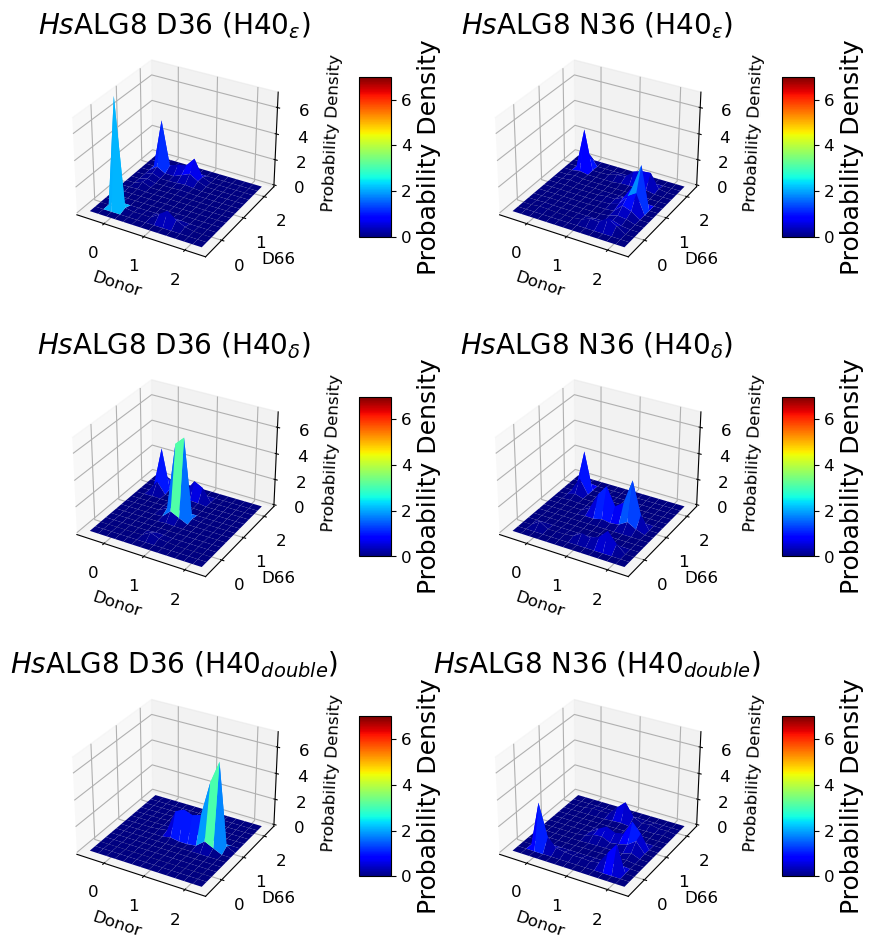

In [20]:
# fig = plt.figure(figsize=plt.figaspect(0.5))
fig, axs = plt.subplots(3,2,figsize=(10,12),dpi=100,subplot_kw={'projection': '3d'})
discard_ratio = 0.8
log = False
cmap = 'Blues'
sliding_window = 20
for i, object_list in enumerate(object_lists):
    acceptor_donor_hbond = np.concatenate([sliding_average(obj.intra_hydrogen_bonds[0,1,int(len(obj.pro_rmsd)*discard_ratio):], 
                                                          window_size=sliding_window) for obj in object_list])
    acceptor_D66_hbond = np.concatenate([sliding_average(obj.protein_substrates_bonds[0,6][int(len(obj.pro_rmsd)*discard_ratio):], 
                                                          window_size=sliding_window) for obj in object_list])
    ax = axs.T.flatten()[i]
    # def plot_hbond_angle(self, ax,r,theta, cmap='Blues',log=False):
    # Plot the histogram in half polar coordinates
    binsize_hbond = 0.2
    Hbond_edges     = np.linspace(-0.5,2.5, 15)

    H, _, _ = np.histogram2d(
        acceptor_donor_hbond,acceptor_D66_hbond ,bins=(Hbond_edges, Hbond_edges),density=True)
    # H[H==0] = np.nan
    x,y  = np.meshgrid(Hbond_edges, Hbond_edges)
    x = 0.5 * (x[:-1,:-1] + x[1:,:-1])
    y = 0.5 * (y[:-1,:-1] + y[:-1,1:])
    im = ax.plot_surface(x,y, H, cmap=plt.cm.jet)
    im.set_clim(0,7)

    ax.set_title(object_names[i])
    ax.set_zlim(0,7)
    ax.set_xlabel("Donor", fontsize=12)
    ax.set_ylabel("D66", fontsize=12)
    ax.set_zlabel('Probability Density', fontsize=12)
    fig.colorbar(im, ax=ax, orientation='vertical',label='Probability Density',shrink=0.6, aspect=5, pad=0.2)

# plt.tight_layout()
filename = figdir+'Hbond_Acceptor_3D.png'
plt.savefig(filename)



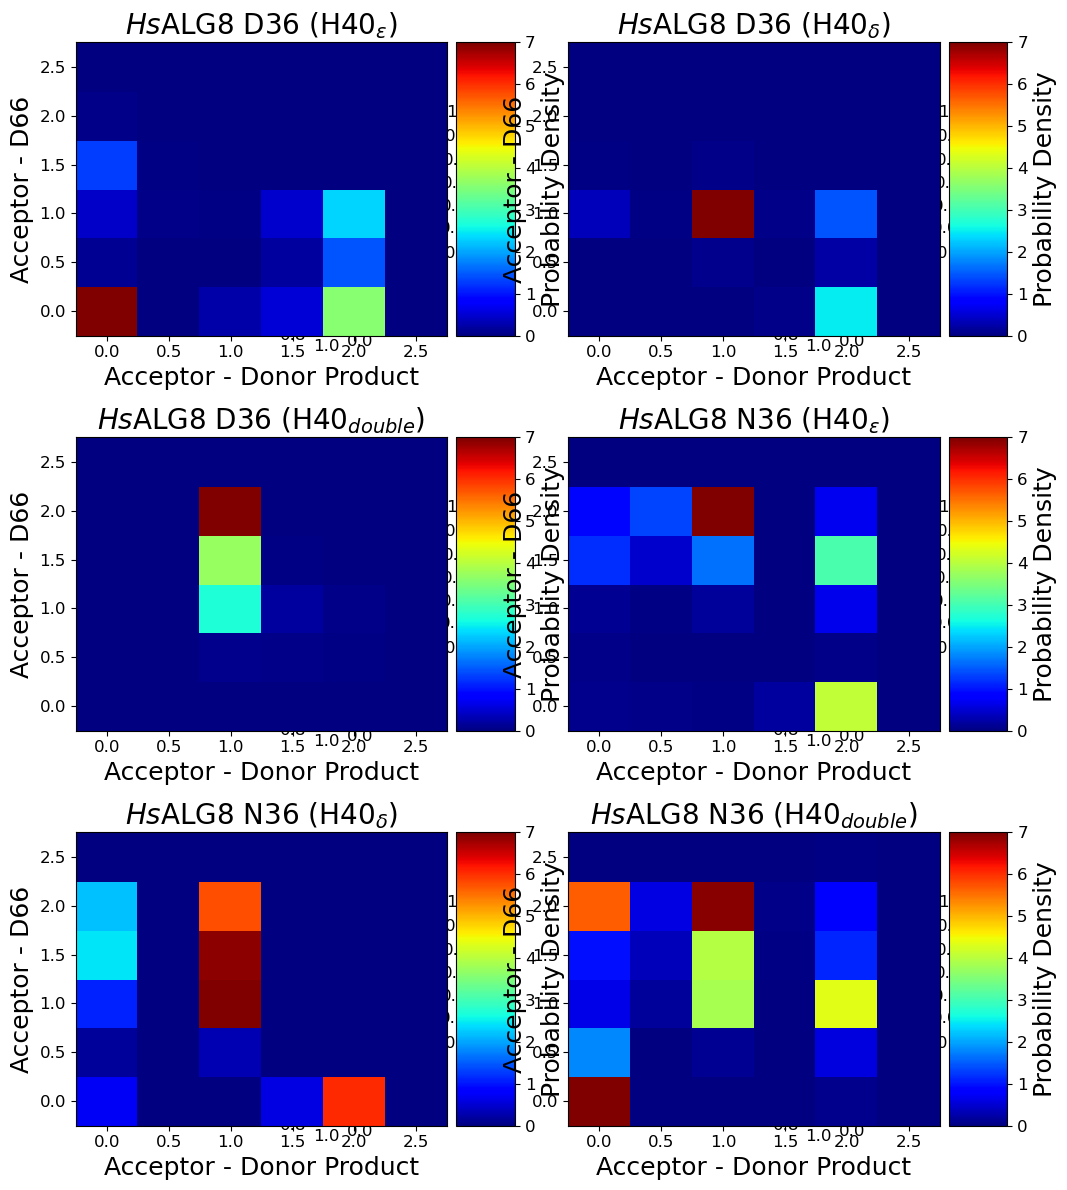

In [21]:
# fig = plt.figure(figsize=plt.figaspect(0.5))
fig, axs = plt.subplots(3,2,figsize=(10,12),dpi=100,subplot_kw={'projection': '3d'})

log = False
cmap = 'Blues'
sliding_window = 20
for i, object_list in enumerate(object_lists):
    ax = axs.T.flatten()[i]
    acceptor_donor_hbond = np.concatenate([sliding_average(obj.intra_hydrogen_bonds[0,1,int(len(obj.pro_rmsd)*discard_ratio):], 
                                                          window_size=sliding_window) for obj in object_list])
    acceptor_D66_hbond = np.concatenate([sliding_average(obj.protein_substrates_bonds[0,6][int(len(obj.pro_rmsd)*discard_ratio):], 
                                                          window_size=sliding_window) for obj in object_list])
    ax = fig.add_subplot(3,2,i+1)
    # def plot_hbond_angle(self, ax,r,theta, cmap='Blues',log=False):
    # Plot the histogram in half polar coordinates
    binsize_r = 0.3
    binsize_theta = 180/50
    Hbond_edges     = np.linspace(-0.25,2.75, 7)
    ax.hist2d(acceptor_donor_hbond, acceptor_D66_hbond ,bins=(Hbond_edges, Hbond_edges),density=True,cmap=plt.cm.jet)
    ax.set_title(object_names[i])
    ax.set_xlabel("Acceptor - Donor Product")
    ax.set_ylabel("Acceptor - D66")
    # ax.set_xticks(np.arange(3,16,2))

    fig.colorbar(im, ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5, pad=0.02)
plt.tight_layout()
# plt.tight_layout()
filename = figdir+'Hbond_Acceptor_2D.png'
plt.savefig(filename)



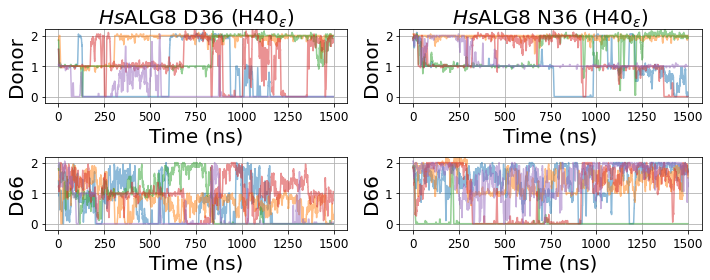

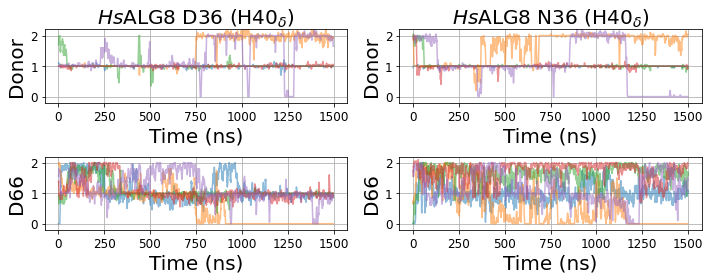

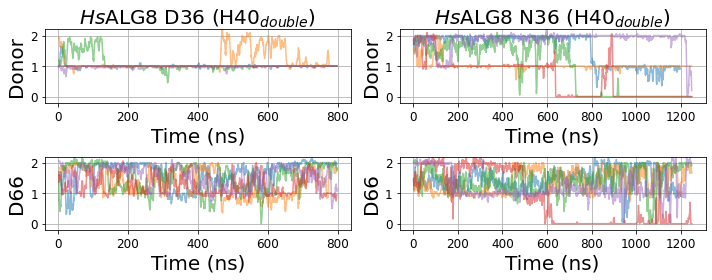

In [22]:
# 1D plots and saving
suffixes = ['H40epsilon', 'H40delta', 'H40double']
ylim = [-0.2,2.2]
for offset in range(3):
    fig, axs = plt.subplots(2, 2, figsize=(10,4))
    for i, object_list in enumerate([object_lists[offset], object_lists[offset+3]]):
        ax1 = axs[0,i]
        ax2 = axs[1,i]
        for i_obj, obj in enumerate(object_list):
            # x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)]
            y = sliding_average(obj.intra_hydrogen_bonds[0,1], window_size=sliding_window)
            x = sliding_average(np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)], window_size=sliding_window)
            ax1.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
            y = sliding_average(obj.protein_substrates_bonds[0,6], window_size=sliding_window) # D66 hbond
            ax2.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
        # if i_object_list == 0:
        #    ax.legend(ncol=3)
        ax1.set_ylim(ylim)
        ax1.set_title(object_names[i*3+offset])
        ax1.set_xlabel('Time (ns)', fontsize=20)
        ax1.set_ylabel('Donor', fontsize=20)
        ax1.grid()
        ax2.set_ylim(ylim)
        ax2.set_xlabel('Time (ns)', fontsize=20)
        ax2.set_ylabel('D66', fontsize=20)
        ax2.grid()

    plt.tight_layout()
    filename = figdir+f'1D_D66_Donor_Interaction_{suffixes[offset]}.png'
    plt.savefig(filename, dpi=300)


## Hbond with F163 and H162

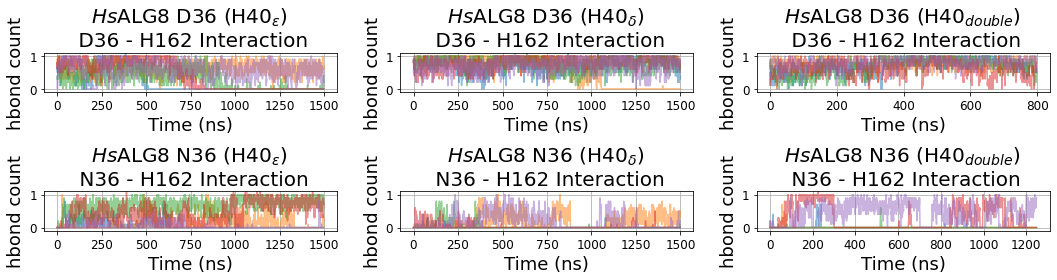

In [23]:
# N36 - F163/H162
fig, axs = plt.subplots(2,3,figsize=(2.5*len(object_lists),4))
axs = axs.flatten()
ylim = [-0.1,1.1]
xlabel = 'Hbond'
ylabel = 'Count'
sliding_window = 10
discard_ratio = 0.1
N36_index = 0
H162_index = 1
for i_object_list, object_list in enumerate(object_lists):
    ax = axs[i_object_list]
    for i_obj, obj in enumerate(object_list):
        recname = obj.rec_name[H162_index]
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)][:-sliding_window+1]
        y = sliding_average(obj.protein_inter_hbonds[N36_index,H162_index],window_size=sliding_window)
        ax.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
        ax.grid()
        ax.set_xlabel('Time (ns)')
        ax.set_ylabel(r'hbond count')
        ax.set_ylim(ylim)
        if i_object_list // 3 == 0:
            ax.set_title(f'{object_names[i_object_list]} \n D36 - H162 Interaction')
        else:
            ax.set_title(f'{object_names[i_object_list]} \n N36 - H162 Interaction')
# axs.legend(ncol=3)
plt.tight_layout()
filename = figdir+'/DN36-H162_hbond.png'
plt.savefig(filename, dpi=300)
        

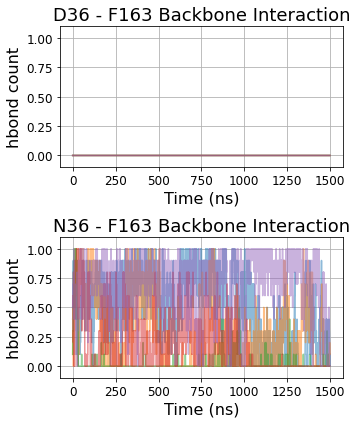

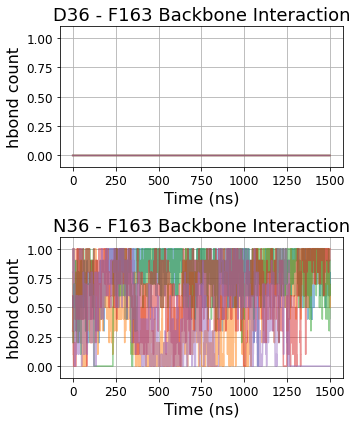

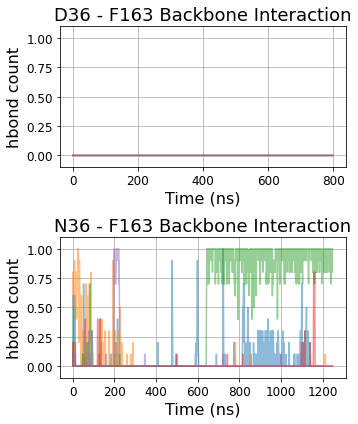

In [24]:
# N36 - F163/H162

ylim = [-0.1,1.1]
xlabel = 'Hbond'
ylabel = 'Count'
sliding_window = 10
discard_ratio = 0.1
N36_index = 0
H162_index = 1
F163_index = 8
for offset in range(3):
    fig, axs = plt.subplots(2, 1,figsize=(5,6))
    show_id = [offset, offset+3]
    for i_object_list, object_list in enumerate([object_lists[j] for j in show_id]):
        ax = axs[i_object_list]
        for i_obj, obj in enumerate(object_list):
            x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)][:-sliding_window+1]
            recname = obj.rec_name[F163_index]
            y = sliding_average(obj.protein_inter_hbonds[N36_index,F163_index],window_size=sliding_window)
            ax.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
        ax.set_xlabel('Time (ns)', fontsize=16)
        ax.set_ylabel(r'hbond count', fontsize=16)
        ax.set_ylim(ylim)
        ax.grid()
        if i_object_list  == 0:
            # ax.set_title(f'{object_names[show_id[0]]} \n D36 - F163 Interaction', fontsize=20)
            ax.set_title(f'D36 - F163 Backbone Interaction', fontsize=18)
        else:
            ax.set_title(f'N36 - F163 Backbone Interaction', fontsize=18)
    plt.tight_layout()
    filename = figdir+f'/N36_F163_interactions_{suffixes[offset]}.png'
    plt.savefig(filename, dpi=300)
        

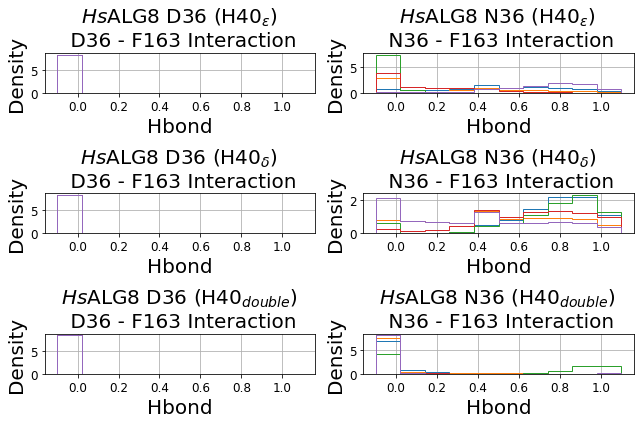

In [25]:
# N36 - F163/H162

axs = axs.flatten()
# ylim = [-0.1,1.1]
xlabel = 'Hbond'
ylabel = 'Count'
sliding_window = 10
discard_ratio = 0.1
N36_index = 0
H162_index = 1
F163_index = 8
bins = np.linspace(-0.1, 1.1, 11)
fig, axs = plt.subplots(len(object_lists)//2, 2,figsize=(9,6))
for i_object_list, object_list in enumerate(object_lists):
    # ax = axs.flatten()[i_object_list]
    ax = axs.T.flatten()[i_object_list]
    for i_obj, obj in enumerate(object_list):
        x = np.arange(0,len(obj.pro_rmsd)*0.2,0.2)[:len(obj.pro_rmsd)][:-sliding_window+1]
        recname = obj.rec_name[F163_index]
        y = sliding_average(obj.protein_inter_hbonds[N36_index,F163_index],window_size=sliding_window)
        ax.hist(y, bins=bins, label = f'Run {i_obj+1}',alpha=1, density=True, histtype='step')
    ax.set_xlabel('Hbond', fontsize=20)
    ax.set_ylabel(r'Density', fontsize=20)
    # ax.set_ylim(ylim)
    ax.grid()
    if i_object_list // 3 == 0:
        ax.set_title(f'{object_names[i_object_list]} \n D36 - F163 Interaction', fontsize=20)
    else:
        ax.set_title(f'{object_names[i_object_list]} \n N36 - F163 Interaction', fontsize=20)
plt.tight_layout()
filename = figdir+'/N36_F163_interactions_histogram.png'
plt.savefig(filename, dpi=300)
        

# H40 torsion

In [26]:
print_out_freq = 5 # 5 frames per ns

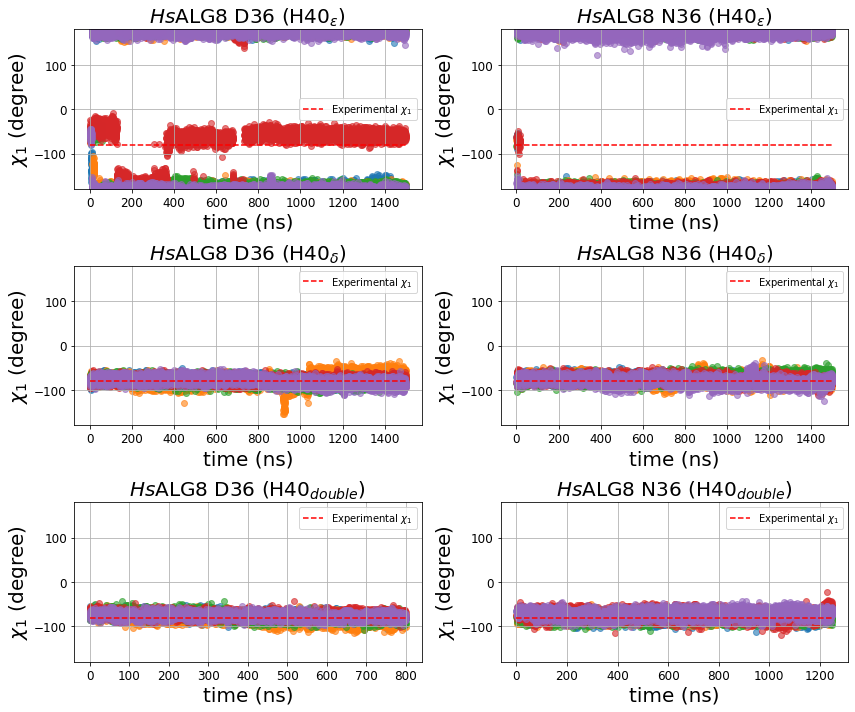

In [27]:
exp_chi1 = -80.29
log = False
cmap = 'Blues'
fig, axs = plt.subplots(len(object_lists)//2, 2,figsize=(12,10))
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.T.flatten()[i_object_list]
    for i_obj, obj in enumerate(object_list):
        torsion = obj.H40_torsion_chi1
        ax.scatter(np.arange(0,len(torsion)/print_out_freq,1/print_out_freq), torsion, alpha=0.6)
    ax.set_title(object_names[i_object_list], fontsize=20)
    ax.hlines(exp_chi1, 0, len(torsion)/print_out_freq, colors='r', linestyles='dashed', label='Experimental $\chi_1$')
    ax.set_ylabel(r'$\chi_1$ (degree)', fontsize=20)
    ax.set_xlabel(r'time (ns)', fontsize=20)
    ax.set_ylim([-180,180])
    ax.grid()
    ax.legend()
plt.tight_layout()
filename = figdir+'H40_torsion_chi1.png'
plt.savefig(filename)


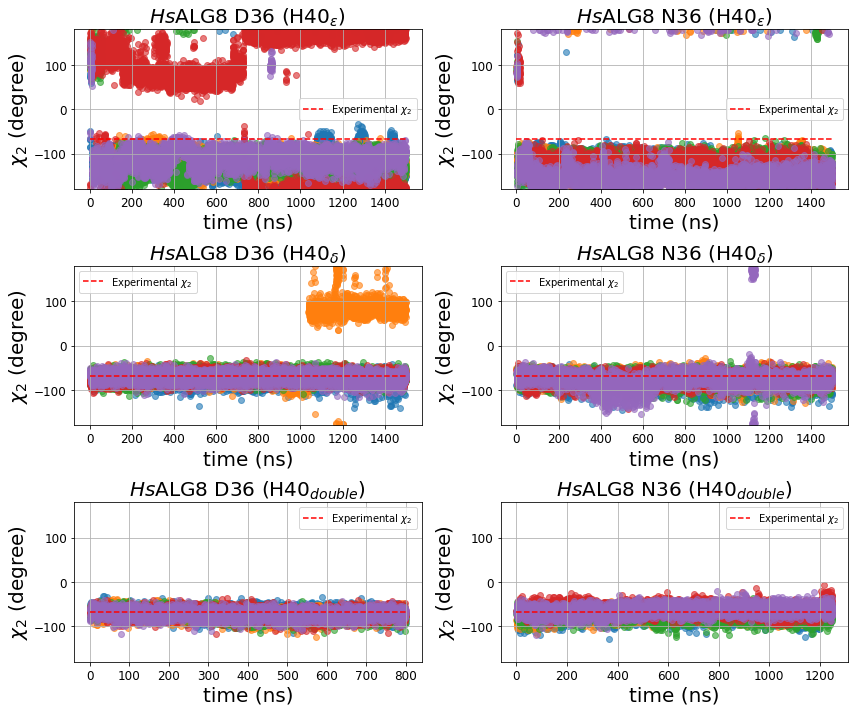

In [28]:
exp_chi2 = -67.94
log = False
cmap = 'Blues'
fig, axs = plt.subplots(len(object_lists)//2, 2,figsize=(12,10))
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.T.flatten()[i_object_list]
    for i_obj, obj in enumerate(object_list):
        torsion = obj.H40_torsion_chi2
        ax.scatter(np.arange(0,len(torsion)/print_out_freq,1/print_out_freq), torsion, alpha=0.6)
    ax.set_title(object_names[i_object_list], fontsize=20)
    ax.hlines(exp_chi2, 0, len(torsion)/print_out_freq, colors='r', linestyles='dashed', label='Experimental $\chi_2$')
    ax.set_ylabel(r'$\chi_2$ (degree)', fontsize=20)
    ax.set_xlabel(r'time (ns)', fontsize=20)
    ax.set_ylim([-180,180])
    ax.grid()
    ax.legend()
plt.tight_layout()
filename = figdir+'H40_torsion_chi2.png'
plt.savefig(filename)


# D36 z-axis

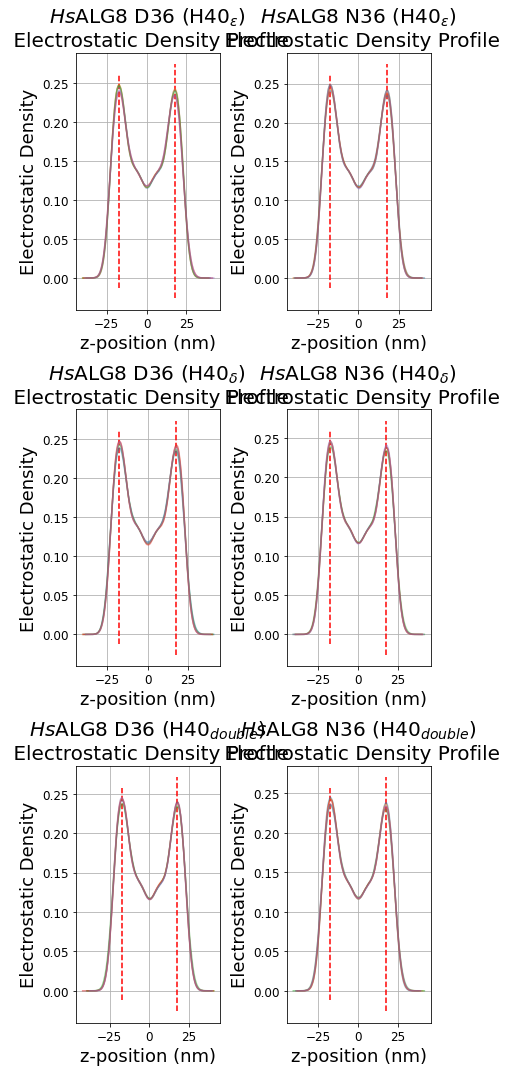

In [29]:
# N36 - F163/H162
fig, axs = plt.subplots(3,2,figsize=(6,15))
axs = axs.T.flatten()
z_lipid = [-17.6, 17.6]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs[i_object_list]
    for i_obj, obj in enumerate(object_list):
        x, E, _ = obj.ele_density.T
        ax.plot(x,E, label = f'Run {i_obj+1}',alpha=0.5)
    ax.set_title(f'{object_names[i_object_list]} \n Electrostatic Density Profile')
    ax.set_xlabel('z-position (nm)')
    ax.set_ylabel(r'Electrostatic Density')
    ax.grid()
for ax in axs:
    for z in z_lipid:
        ax.vlines(z, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], color='red', linestyle='--', alpha=1)
plt.tight_layout()
filename = figdir+'/Electrostatic_density_profile.png'
plt.savefig(filename, dpi=300)

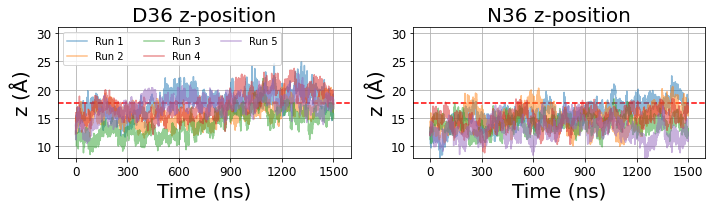

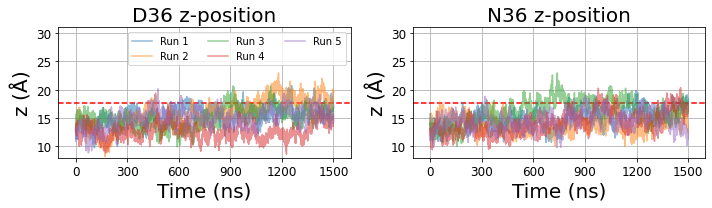

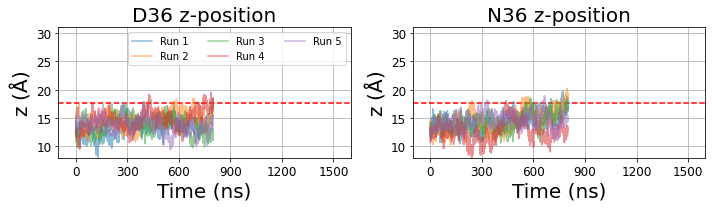

In [61]:
# N36 - F163/H162
axs = axs.T.flatten()
ylim = [8,31]
xlim = [-100,1600]
xticks = np.arange(0,1501,300)
for offset in range(3):
    # fig, axs = plt.subplots(1,2,figsize=(10,3))
    fig, axs = plt.subplots(1,2, figsize=(10,3))
    use_id  = [offset, offset+3]
    for i_object_list, object_list in enumerate([object_lists[j] for j in use_id]):
        ax = axs[i_object_list]
        for i_obj, obj in enumerate(object_list):
            y = obj.D36_z[:len(obj.pro_rmsd)]
            x = np.arange(0,len(y)*0.2-0.01,0.2)
            ax.plot(x, y, label = f'Run {i_obj+1}',alpha=0.5)
        ax.set_xlabel('Time (ns)', fontsize=20)
        ax.set_ylabel(r'z ($\rm \AA$)', fontsize=20)
        ax.grid()
        ax.set_ylim(ylim)
        ax.set_xlim(xlim)
        ax.set_xticks(xticks)
        
        title = object_names[use_id[i_object_list]]
        if 'N36' in title:
            # ax.set_title(f'{title} \n N36 z-position', fontsize=20)
            ax.set_title(f'N36 z-position', fontsize=20)
        else:
            ax.set_title(f'D36 z-position', fontsize=20)

    plt.tight_layout()
    axs[0].legend(ncol=3)
    for ax in axs:
        for z in z_lipid:
            ax.hlines(z, xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], color='red', linestyle='--', alpha=1)
    filename = figdir+f'/D36_z_position_time_{suffixes[offset]}.png'
    plt.savefig(filename, dpi=300)
filename = figdir+'/N36_F163_interactions.png'
plt.savefig(filename, dpi=300)


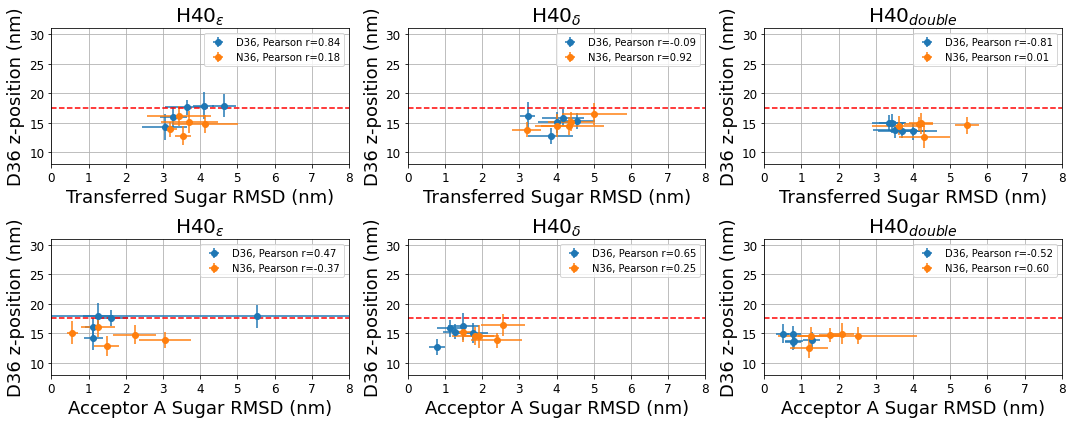

In [31]:
discard_frames = 800
xlim = [0, 8]
fig, axs = plt.subplots(2,3,figsize=(15,6))
for i_object_list, object_list in enumerate(object_lists):
    
    DS_data = np.zeros([len(object_list), 2]) # avg, std
    AS_data = np.zeros_like(DS_data)
    D36_data = np.zeros_like(DS_data)
    for i_obj, obj in enumerate(object_list):
        # D36_z
        D36_z = obj.D36_z[discard_frames:]
        D36_data[i_obj] = np.mean(D36_z), np.std(D36_z)
        # AS
        AS = obj.A_sugar_rmsd[discard_frames:]
        AS_data[i_obj] = np.mean(AS), np.std(AS)
        # DS
        DS_rmsd = obj.DS_rmsd[discard_frames:]
        DS_data[i_obj] = np.mean(DS_rmsd), np.std(DS_rmsd)
        
    # plot AS vs D36_z
    ax = axs[:,i_object_list%3]
    pearson_r = np.corrcoef(DS_data[:,0], D36_data[:,0])[0,1]
    ax[0].errorbar(DS_data[:,0], D36_data[:,0], xerr=DS_data[:,1], yerr=D36_data[:,1], fmt='o', label=f"{object_names[i_object_list].split(' ')[1]}, Pearson r={pearson_r:.2f}")
    pearson_r = np.corrcoef(AS_data[:,0], D36_data[:,0])[0,1]
    ax[1].errorbar(AS_data[:,0], D36_data[:,0], xerr=AS_data[:,1], yerr=D36_data[:,1], fmt='o', label=f"{object_names[i_object_list].split(' ')[1]}, Pearson r={pearson_r:.2f}")
    ax[0].set_title(object_names[i_object_list].split(' ')[2][1:-1])
    ax[1].set_title(object_names[i_object_list].split(' ')[2][1:-1])
    ax[0].set_xlabel(r'Transferred Sugar RMSD (nm)')
    ax[1].set_xlabel(r'Acceptor A Sugar RMSD (nm)')   
    
for ax in axs.flatten():
    ax.hlines(z_lipid[1], xmin=xlim[0], xmax=xlim[1] , color='red', linestyle='--', alpha=1)
    ax.grid()
    ax.set_ylabel('D36 z-position (nm)')
    ax.set_ylim(ylim)
    ax.set_xlim(xlim)
    ax.legend()
plt.tight_layout()
filename = figdir+'/D36_z_RMSD_correlation.png'
plt.savefig(filename, dpi=300)

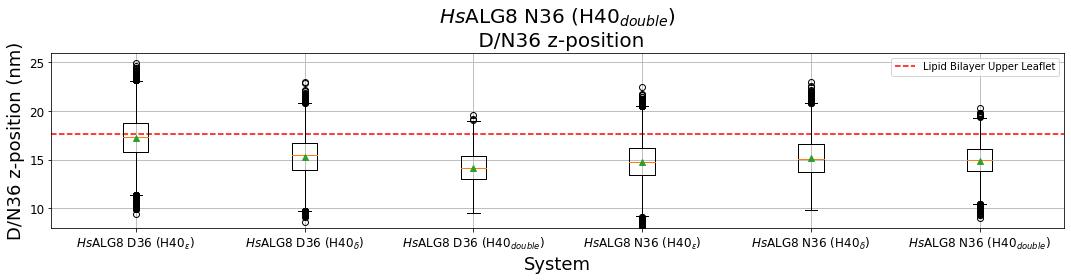

In [32]:
# N36 - F163/H162
fig, ax = plt.subplots(1,1,figsize=(2.5*len(object_lists),4))
discard_frames = 2400
ylim = [8,26]
for i_object_list, object_list in enumerate(object_lists):
    z_total = []
    for i_obj, obj in enumerate(object_list):
        z = obj.D36_z
        mask = np.arange(0,len(z)) >= discard_frames
        z_total.append(z[mask])
    ax.boxplot(np.concatenate(z_total), positions=[i_object_list], showmeans=True)
ax.set_xlabel('System')
ax.set_ylabel(r'D/N36 z-position (nm)')
ax.set_xticks(np.arange(len(object_lists)))
ax.grid()
ax.set_ylim(ylim)
ax.set_title(f'{object_names[i_object_list]} \n D/N36 z-position')
ax.set_xticklabels([name for name in object_names], )
plt.tight_layout()
ax.hlines( z_lipid[1], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], color='red', linestyle='--', alpha=1, label='Lipid Bilayer Upper Leaflet')
ax.legend()
filename = figdir+'/D36_z_position_boxplot.png'
plt.savefig(filename, dpi=300)
